In machine learning, bias and variance represent different types of errors that a model can make. Bias is the error due to the model's assumptions, while variance is the error due to the model's sensitivity to the training data. To calculate them, you can use formulas or rely on libraries that provide functions for bias-variance decomposition. [1, 2, 3]  
1. Mathematical Definition: 

• Bias: The difference between the expected prediction of a model and the true value. A high bias means the model is too simple and misses important patterns in the data.  

• Variance: The variability of a model's predictions across different training datasets. A high variance means the model is too complex and is overfitting to the training data. [2, 4]  

2. Formula for Bias and Variance: [1, 2, 3]  

• Bias: Bias(ˆθ) = E[ˆθ] - θ where ˆθ is the predicted value and θ is the true value. The E operator denotes the expected value.  

• Variance: Var(ˆθ) = E[(E[ˆθ] - ˆθ)²] where ˆθ is the predicted value and E[ˆθ] is the expected prediction. [1, 1, 5, 6]  

3. Practical Calculation and Tools: [7, 7, 8, 8]  

• Split Data: Split your dataset into training and testing sets. [7, 7, 8, 8]  
• Retrain and Predict: Train your model on the training set and make predictions on the testing set. [8, 8]  
• Calculate Error: Calculate the error (e.g., Mean Squared Error, MSE) for each training-test set. [8, 8, 9, 9, 10]  
• Bias-Variance Decomposition: Use libraries like mlxtend in Python, which offers functions to calculate bias and variance decomposition. [3, 3, 11, 12]  
• Cross-Validation: Use k-fold cross-validation to get a more robust estimate of bias and variance. [8, 8, 13, 13]  

4. Interpreting Results: [4, 4, 14, 14]  

• High Bias (Underfitting): The model is too simplistic and doesn't capture the underlying patterns in the data. The training error and test error are both high. [4, 4, 14, 14, 15]  
• High Variance (Overfitting): The model is too complex and is overfitting to the training data. The training error is low, but the test error is high. [4, 4, 5, 12, 14, 14, 15, 15]  
• Balanced Bias and Variance: The model is a good fit for the data, with a good balance between simplicity and capturing complexity. [4, 12, 16, 17]  

For a more detailed explanation and code examples, you can refer to articles and videos https://www.appliedaicourse.com/blog/bias-and-variance-in-machine-learning/, https://www.youtube.com/watch?v=EuBBz3bI-aA&pp=0gcJCdgAo7VqN5tD,. [2, 3, 7]  

Generative AI is experimental.

[1] https://rasbt.github.io/mlxtend/user_guide/evaluate/bias_variance_decomp/[2] https://www.appliedaicourse.com/blog/bias-and-variance-in-machine-learning/[3] https://www.bmc.com/blogs/bias-variance-machine-learning/[4] https://www.simplilearn.com/tutorials/machine-learning-tutorial/bias-and-variance[5] https://www.geeksforgeeks.org/bias-vs-variance-in-machine-learning/[6] https://dev.to/anurag629/bias-vs-variance-the-key-to-successful-predictive-modeling-mbp[7] https://www.youtube.com/watch?v=EuBBz3bI-aA&pp=0gcJCdgAo7VqN5tD[8] https://www.reddit.com/r/learnmachinelearning/comments/w3rwxm/how_to_measure_bias_and_variance_in_ml_models/[9] https://stackoverflow.com/questions/55266588/bias-and-variance-calculation-for-linear-regression[10] https://www.mastersindatascience.org/learning/difference-between-bias-and-variance/[11] https://www.studeersnel.nl/nl/messages/question/11324028/the-biasvariance-decomposition-is-a-helpful-tool-which-is-falsewe-can-estimate-the[12] https://www.linkedin.com/advice/3/how-do-you-balance-bias-variance-your-machine-learning-tdx5e[13] https://towardsdatascience.com/machine-learning-bias-variance-tradeoff-and-regularization-94846f945131/[14] https://kili-technology.com/data-labeling/machine-learning/bias-estimation-a-complete-guide-for-machine-learning-engineers[15] https://www.kaggle.com/general/219378[16] https://arxiv.org/pdf/2011.02952[17] https://datascience.stackexchange.com/questions/80157/what-are-bias-and-variance-in-machine-learning


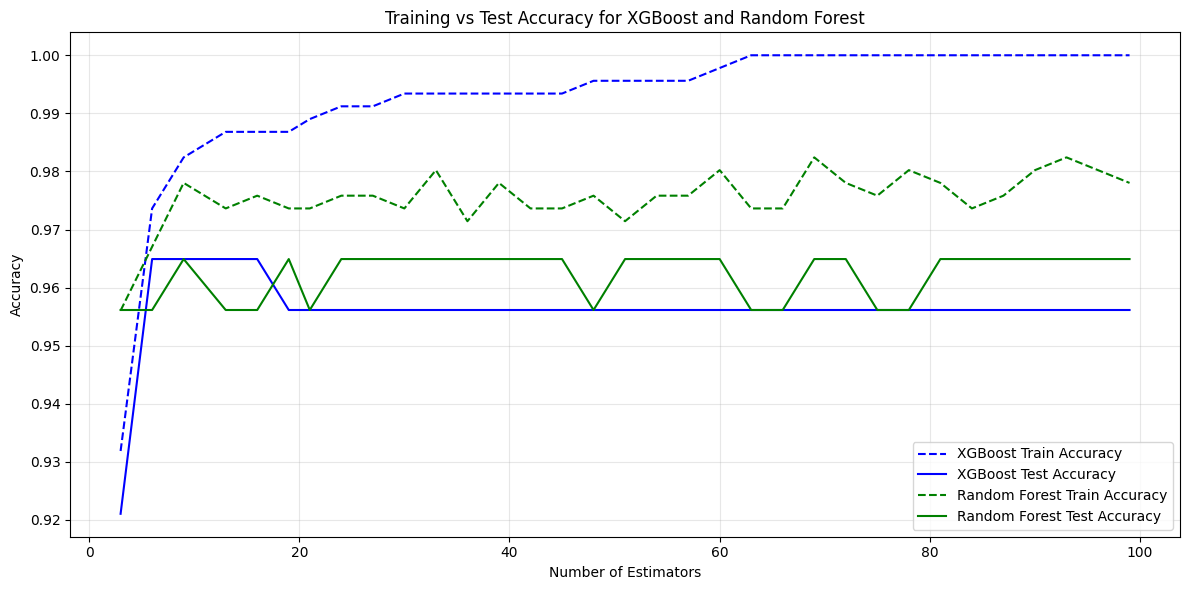

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the number of estimators
ESTIMATORS = [3, 6, 9, 13, 16, 19, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99]

# Function to calculate train and test scores
def calculate_scores(model_class, **kwargs):
    train_scores = []
    test_scores = []
    for n_est in ESTIMATORS:
        model = model_class(n_estimators=n_est, **kwargs)
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        train_scores.append(accuracy_score(y_train, y_train_pred))
        test_scores.append(accuracy_score(y_test, y_test_pred))
    return train_scores, test_scores

# Calculate scores for XGBoost
xgb_train_scores, xgb_test_scores = calculate_scores(xgb.XGBClassifier, learning_rate=0.1, max_depth=3)#, random_state=42)

# Calculate scores for Random Forest
rf_train_scores, rf_test_scores = calculate_scores(RandomForestClassifier, max_depth=3)#, random_state=42)

# Plot the results
plt.figure(figsize=(12, 6))

# XGBoost
plt.plot(ESTIMATORS, xgb_train_scores, label="XGBoost Train Accuracy", color="blue", linestyle="--")
plt.plot(ESTIMATORS, xgb_test_scores, label="XGBoost Test Accuracy", color="blue")

# Random Forest
plt.plot(ESTIMATORS, rf_train_scores, label="Random Forest Train Accuracy", color="green", linestyle="--")
plt.plot(ESTIMATORS, rf_test_scores, label="Random Forest Test Accuracy", color="green")

# Add labels, legend, and grid
plt.title("Training vs Test Accuracy for XGBoost and Random Forest")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()